In [1]:
import sys
sys.path.insert(1, '../src/')
from raw_data_preprocessing import *

In [2]:
DATASET = "Merkuriusz"

In [3]:
import matplotlib.pyplot as plt
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

RAW_DATA_PATH = config["raw_data_path"][DATASET]
PREPROCESSED_DATA_PATH = config["preprocessed_data_path"][DATASET]
ELEMENTS_DICT = config["elements_dict"]
N_STD = config["n_std"]
ROW_NR = config["row_nr"]
N_DES = config["n_des"]
N = config["n"]
BUNCH_NO = config["bunch_no"]
TO_FE = config["to_fe"]
KEEP_FE = config["keep_fe"]

### Preprocessing step 

In [4]:
# # load raw
# #filename = 'Cop_61.xl'
# filename = 'Mer_1.xl'

# raw_df = read_raw_file(RAW_DATA_PATH + filename)

# # ensure expected columns selected (elements_dict should be defined in module or imported)
# selected = select_expected_columns(raw_df, ELEMENTS_DICT)

# # initial rounding and despike
# cleaned = round_and_despike_df(selected)

# # normalize by elements_dict mapping
# normalized = normalize_by_elements_dict(cleaned, ELEMENTS_DICT)

# # subtract blank and clip
# normalized_blank = subtract_blank_and_clip(normalized, n_std=N_STD, row_nr=ROW_NR)

# # optional additional despike passes
# despike_df = apply_multiple_despike(normalized_blank, n_des=N_DES)

# # sort and create bunches
# bunched = sort_and_bunch(despike_df)

# # optional normalize to Fe
# if False:
#     bunched = normalize_to_fe(bunched)

# # add names column and return
# bunched = add_names_column(bunched, RAW_DATA_PATH + filename)

In [5]:
# equivalent to:
# res = machine(RAW_DATA_PATH + 'BUWo1.xl', ELEMENTS_DICT)

In [6]:
selected.columns = despike_df.columns
cleaned.columns = despike_df.columns

dfs = [selected, cleaned, normalized, normalized_blank, despike_df, bunched]
preprocessing_steps = ['raw', 'round and despike', 'subtract blank and clip', 'normalize', 'multiple despike', 'bunch']

### Visualisation

In [7]:
el = 'S'

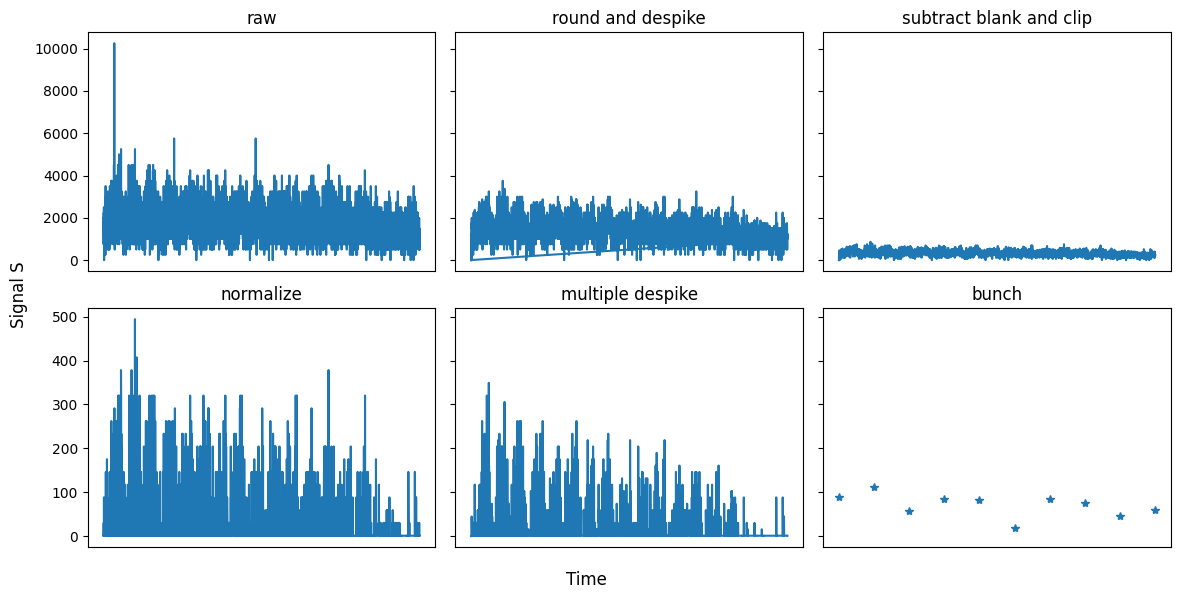

In [8]:
# Create figure and subplots: 2 rows, 3 columns
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(12, 6),
    sharey='row'
)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot each data vector
for i, ax in enumerate(axes):
    if i == 5:
        ax.plot(dfs[i][el], '*')
    else:
        ax.plot(dfs[i][el])
    ax.set_title(preprocessing_steps[i])
    ax.set_xticks([])

# Label shared axes
fig.supxlabel('Time')
fig.supylabel('Signal ' + el)

# Improve layout
plt.tight_layout()
plt.show()

### Saving

In [9]:
preprocessing_results = preprocess_all_from_directory(
                                                        raw_data_path = RAW_DATA_PATH, 
                                                        elements_dict = ELEMENTS_DICT, 
                                                        preprocessed_data_path = PREPROCESSED_DATA_PATH,
                                                        n_std = N_STD, 
                                                        row_nr = ROW_NR, 
                                                        n_des = N_DES, 
                                                        n = N, 
                                                        bunch_no = BUNCH_NO, 
                                                        to_fe = TO_FE, 
                                                        keep_fe = KEEP_FE,
                                                        sort=True
                                                    )

(120, 21)
